# FDTDX Simulation Symmetry: Waveguide Taper

This notebook demonstrates FDTDX's mirror-symmetry feature: a waveguide taper that is
symmetric in **y** (width) and **z** (thickness) can be simulated on **one quarter** of
the physical volume.

## 1. Imports and setup

In [55]:
import time
import fdtdx
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Video

%matplotlib inline


## 2. Physical parameters

In [58]:
wavelength = 1.55e-6            # 1.55 um
c0 = 299_792_458.0
frequency = c0 / wavelength

# Taper geometry: narrow tip w1 -> wide end w2, over length L, thickness h
w1, w2, h, L = 0.20e-6, 0.60e-6, 0.20e-6, 1.2e-6

# Simulation domain
domain_x, domain_y, domain_z = 3.0e-6, 1.6e-6, 1.2e-6
pml_thickness = 8          # PML cells on each face
dx = 0.025e-6               # 25 nm resolution

grid_shape = (
    int(np.ceil(domain_x / dx)),
    int(np.ceil(domain_y / dx)),
    int(np.ceil(domain_z / dx)),
)
# Both symmetric axes (y, z) must resolve to an EVEN number of cells so the
# domain splits exactly down the middle
grid_shape = (grid_shape[0], grid_shape[1] + grid_shape[1] % 2, grid_shape[2] + grid_shape[2] % 2)
print("grid shape, full domain   :", grid_shape)
print("grid shape, quarter domain:", (grid_shape[0], grid_shape[1] // 2, grid_shape[2] // 2))

n_periods = 30
total_time = n_periods / frequency

n_si, n_bg = 3.48, 1.0          # silicon core, air background/cladding
mat_si = fdtdx.Material(permittivity=n_si**2)
mat_bg = fdtdx.Material(permittivity=n_bg**2)

master_key = jax.random.PRNGKey(0)
def next_key():
    global master_key
    master_key, sub = jax.random.split(master_key)
    return sub


grid shape, full domain   : (121, 64, 48)
grid shape, quarter domain: (121, 32, 24)


## 3. Geometry: the taper as a staircase of boxes

In [61]:
N_SEG = 16  # number of straight segments approximating the linear taper

w1_cells, w2_cells, h_cells = round(w1 / dx), round(w2 / dx), round(h / dx)
assert w1_cells % 2 == 0 and w2_cells % 2 == 0 and h_cells % 2 == 0, (
    "taper cross-section must resolve to an even number of grid cells on both "
    "symmetric axes (y, z) for the mirrored geometry to be exact"
)
seg_len_cells = max(1, round((L / dx) / N_SEG))
print(f"segments: {N_SEG} x {seg_len_cells} cells long, width {w1_cells}->{w2_cells} cells, "
      f"thickness {h_cells} cells")


segments: 16 x 3 cells long, width 8->24 cells, thickness 8 cells


## 4. Build function: `symmetry=(0, 0, 0)` for the full volume, `symmetry=(0, -1, +1)` for the quarter volume

`-1` = PEC (electric wall) and `+1` = PMC (magnetic wall). `Ey`, the dominant field component of the fundamental TE-like mode, is the *normal* component across the y=0 plane and the *tangential* component across the z=0 plane.

In [64]:
def build_simulation(symmetry):
    volume = fdtdx.SimulationVolume(partial_grid_shape=grid_shape, material=mat_bg, name="volume")

    
    bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=pml_thickness, boundary_type="pml")
    bound_dict, bound_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)

    center_wave = fdtdx.WaveCharacter(wavelength=wavelength)
    pulse_profile = fdtdx.GaussianPulseProfile(
        center_wave=center_wave, spectral_width=fdtdx.WaveCharacter(frequency=frequency / 10)
    )

    # Taper as a staircase of boxes
    segments, seg_constraints, prev = [], [], None
    for i in range(N_SEG):
        frac = (i + 0.5) / N_SEG  # segment-center fraction along the taper, 0..1
        width_cells_i = w1_cells + 2 * round((w2_cells - w1_cells) * frac / 2)
        seg = fdtdx.UniformMaterialObject(
            name=f"taper_seg_{i}", material=mat_si,
            partial_grid_shape=(seg_len_cells, width_cells_i, h_cells),
        )
        segments.append(seg)
        seg_constraints.append(seg.place_at_center(volume, axes=(1, 2)))
        if prev is not None:
            seg_constraints.append(seg.face_to_face_positive_direction(prev, axes=(0,)))
        prev = seg

    # Mode source at the narrow end (injects +x), mode detector at the wide end
    source = fdtdx.ModePlaneSource(
        pulse_profile, name="source", direction="+", mode_index=0, filter_pol="te",
        wave_character=center_wave, partial_grid_shape=(1, None, None),
    )
    detector = fdtdx.ModeOverlapDetector(
        name="detector", direction="+", mode_index=0, filter_pol="te",
        wave_characters=[center_wave], partial_grid_shape=(1, None, None),
    )
    # Records 2-D energy slices through the run
    energy_detector = fdtdx.EnergyDetector(
        name="energy", switch=fdtdx.OnOffSwitch(interval=6), as_slices=True, num_video_workers=None,
    )
    # Steady-state (frequency-domain) field over the whole volume, for the
    # quantitative full-vs-symmetric comparison.
    field_probe = fdtdx.PhasorDetector(
        name="field_probe", wave_characters=[center_wave], components=("Ex", "Ey", "Ez"),
        scaling_mode="pulse", reduce_volume=False, plot=False,
    )

    objects = [volume, *segments, source, detector, energy_detector, field_probe]
    objects.extend(bound_dict.values())

    constraints = [
        segments[0].place_at_center(volume, axes=(0,)),
        *seg_constraints,
        source.face_to_face_negative_direction(segments[0], axes=(0,)),
        detector.face_to_face_positive_direction(segments[-1], axes=(0,)),
        source.place_at_center(volume, axes=(1, 2)),
        detector.place_at_center(volume, axes=(1, 2)),
        *energy_detector.same_position_and_size(volume),
        *field_probe.same_position_and_size(volume),
    ]
    constraints.extend(bound_constraints)

    config = fdtdx.SimulationConfig(
        time=total_time, grid=fdtdx.UniformGrid(spacing=dx), symmetry=symmetry, backend="cpu",
    )
    return objects, constraints, config, source, detector, energy_detector, field_probe


def run_case(symmetry, tag):
    print(f"--- {tag}: symmetry={symmetry} ---")
    objects, constraints, config, source, detector, energy_detector, field_probe = build_simulation(symmetry)
    placed, arrays, params, config, info = fdtdx.place_objects(
        object_list=objects, config=config, constraints=constraints, key=next_key()
    )
    print(f"{tag}: field grid shape = {arrays.fields.E.shape}, time_steps_total = {config.time_steps_total}, "
          f"source symmetry_profile_multiplicity = {placed[source.name].symmetry_profile_multiplicity}")
    arrays, placed, info = fdtdx.apply_params(arrays, placed, params, next_key())
    t1 = time.time()
    _, arrays = fdtdx.run_fdtd(config=config, objects=placed, arrays=arrays, key=next_key())
    print(f"{tag}: run_fdtd took {time.time()-t1:.1f}s")
    return placed, arrays, config, source, detector, energy_detector, field_probe


## 5. Run the full-volume simulation (`symmetry=(0, 0, 0)`)

In [67]:
placed_full, arrays_full, config_full, src_full, det_full, edet_full, fp_full = run_case(
    (0, 0, 0), "FULL"
)


--- FULL: symmetry=(0, 0, 0) ---
FULL: field grid shape = (3, 121, 64, 48), time_steps_total = 3254, source symmetry_profile_multiplicity = 1


FDTD (checkpointed):   0%|                           | 0/3254 [00:00<?, ?step/s]

FULL: run_fdtd took 6.2s


A quick look at the scene (taper, source, detector, PML) that was just simulated:

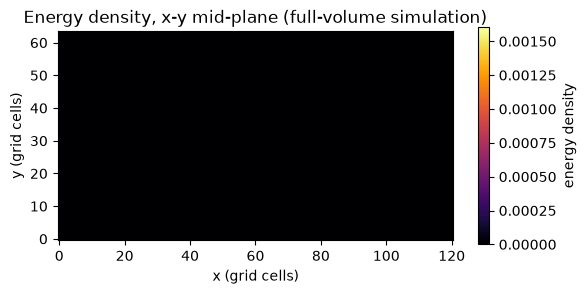

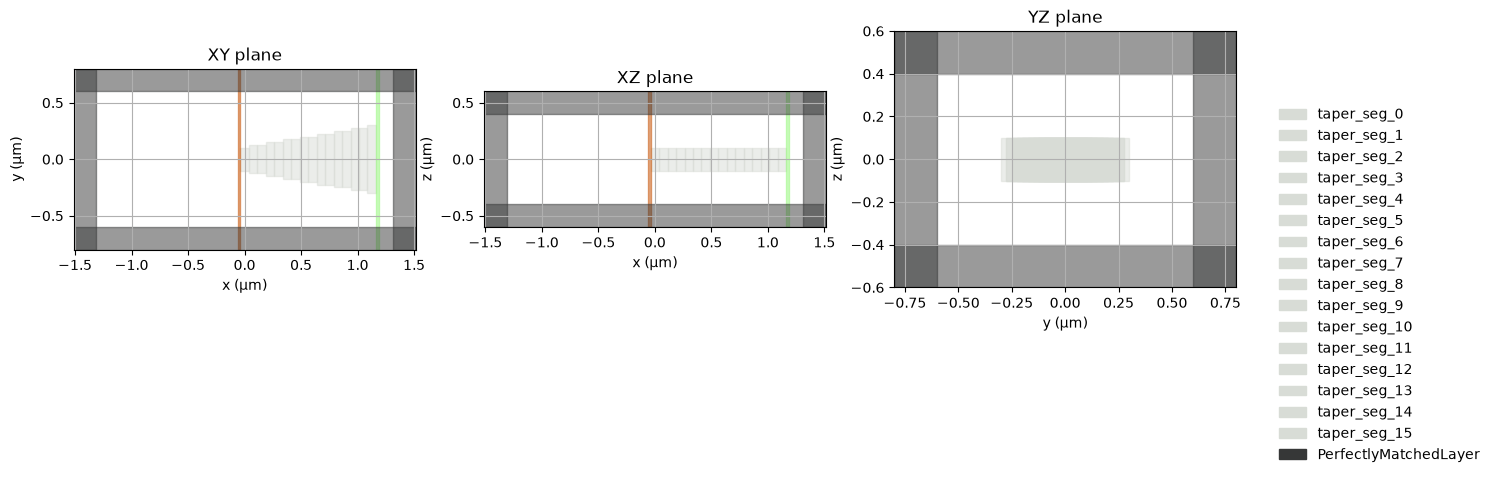

In [70]:
fig = fdtdx.plot_setup(config=config_full, objects=placed_full, exclude_object_list=[edet_full, fp_full])
plt.show()


## 6. Run the quarter-volume simulation (`symmetry=(0, -1, +1)`)

Same code, same physical setup -- only `symmetry` differs. `place_objects()` automatically reduces the domain to one quarter, clips every object onto it, and replaces the two mirrored PML faces with the PEC/PMC symmetry wall.

In [73]:
placed_sym, arrays_sym, config_sym, src_sym, det_sym, edet_sym, fp_sym = run_case(
    (0, -1, 1), "QUARTER (symmetric)"
)


2026-09-12 15:54:27.663 | WARNING  | fdtdx.fdtd.initialization:place_objects:244 - Symmetry (0, -1, 1) reduces the simulation to grid shape (121, 32, 24) (PEC walls added on the electric planes: ['_sym_wall_y']; magnetic planes sit half a cell out and carry their mirror in the field halo, so they get no wall object; objects dropped: ['Object_20', 'Object_22']). Results are on the reduced domain — call fdtdx.unfold_detector_states / fdtdx.unfold_fields to reconstruct the full domain.


--- QUARTER (symmetric): symmetry=(0, -1, 1) ---
QUARTER (symmetric): field grid shape = (3, 121, 32, 24), time_steps_total = 3254, source symmetry_profile_multiplicity = 4


FDTD (checkpointed):   0%|                           | 0/3254 [00:00<?, ?step/s]

QUARTER (symmetric): run_fdtd took 2.2s


## 7. Unfold and compare quantitatively

In [76]:
unfolded_sym = fdtdx.unfold_detector_states(arrays_sym, placed_sym, config_sym)

phasor_full = np.asarray(arrays_full.detector_states[fp_full.name]["phasor"])
phasor_sym_unfolded = np.asarray(unfolded_sym.detector_states[fp_sym.name]["phasor"])
print("full-domain phasor field shape     :", phasor_full.shape)
print("unfolded quarter-domain field shape:", phasor_sym_unfolded.shape)

k_axes = sum(1 for s in config_sym.symmetry if s != 0)
amp_correction = 2 ** (k_axes / 2)
print(f"\nsymmetry axes used: {k_axes}  ->  amplitude correction factor 2**(k/2) = {amp_correction}")
print(f"measured source.symmetry_profile_multiplicity = {placed_sym[src_sym.name].symmetry_profile_multiplicity} "
      f"(= 2**{k_axes} as expected)")

phasor_sym_corrected = phasor_sym_unfolded / amp_correction


def fidelity(a, b):
    a, b = a.ravel(), b.ravel()
    return abs(np.vdot(a, b)) / (np.linalg.norm(a) * np.linalg.norm(b))


fid = fidelity(phasor_full, phasor_sym_corrected)
rel_err = np.linalg.norm(phasor_sym_corrected - phasor_full) / np.linalg.norm(phasor_full)
print(f"\nField fidelity (cosine similarity, full vs. unfolded quarter): {fid:.4f}")
print(f"Relative L2 error after the amplitude correction             : {rel_err:.4f}")


full-domain phasor field shape     : (1, 1, 3, 121, 64, 48)
unfolded quarter-domain field shape: (1, 1, 3, 121, 64, 48)

symmetry axes used: 2  ->  amplitude correction factor 2**(k/2) = 2.0
measured source.symmetry_profile_multiplicity = 4 (= 2**2 as expected)

Field fidelity (cosine similarity, full vs. unfolded quarter): 0.9777
Relative L2 error after the amplitude correction             : 0.2299


In [78]:
overlap_full = placed_full[det_full.name].compute_overlap(arrays_full.detector_states[det_full.name])
overlap_sym = placed_sym[det_sym.name].compute_overlap(arrays_sym.detector_states[det_sym.name])
print(f"Transmission |S| full volume    : {np.abs(np.array(overlap_full))[0]:.4f}")
print(f"Transmission |S| quarter volume : {np.abs(np.array(overlap_sym))[0]:.4f}")


Transmission |S| full volume    : 0.0559
Transmission |S| quarter volume : 0.0442


## 8. Visual comparison

$|E_y|$ in the horizontal (x-y) mid-plane, at steady state: full volume, unfolded quarter volume, and their difference.

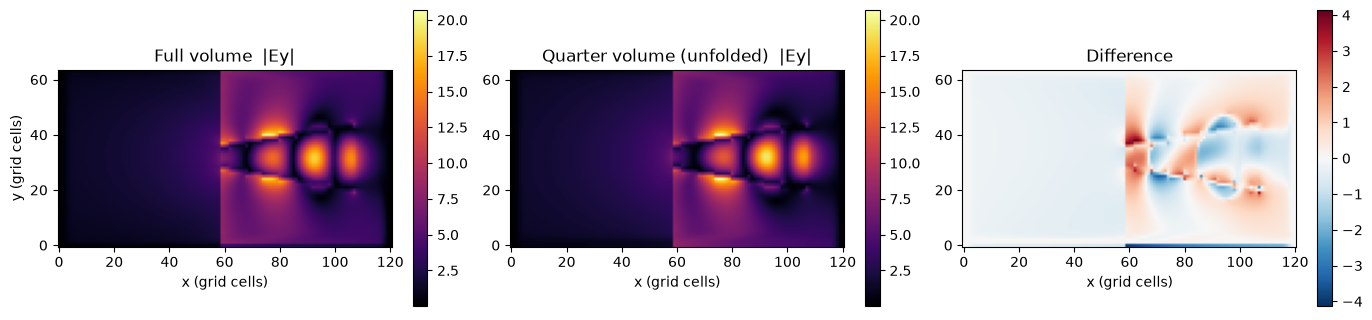

In [81]:
z_mid = phasor_full.shape[-1] // 2
Ey_full = np.abs(phasor_full[0, 0, 1, :, :, z_mid])
Ey_sym = np.abs(phasor_sym_corrected[0, 0, 1, :, :, z_mid])
vmax = max(Ey_full.max(), Ey_sym.max())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im0 = axes[0].imshow(Ey_full.T, origin="lower", cmap="inferno", vmax=vmax)
axes[0].set_title("Full volume  |Ey|")
im1 = axes[1].imshow(Ey_sym.T, origin="lower", cmap="inferno", vmax=vmax)
axes[1].set_title("Quarter volume (unfolded)  |Ey|")
diff = Ey_full - Ey_sym
im2 = axes[2].imshow(diff.T, origin="lower", cmap="RdBu_r", vmin=-vmax * 0.2, vmax=vmax * 0.2)
axes[2].set_title("Difference")
for ax, im in zip(axes, (im0, im1, im2)):
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xlabel("x (grid cells)")
axes[0].set_ylabel("y (grid cells)")
plt.tight_layout()
plt.show()
